# GRAEP Tutorial: Differentiable Analysis in High Energy Physics
## Searching for New Physics with Gradient-Based Optimization

**Duration**: ~20 minutes

**Learning Objectives**:
1. Understand the Z' → ttbar analysis
2. Learn how to make cuts and histogramming differentiable
3. Optimize the significance using automatic differentiation

---

## Part 1: Introduction to the Analysis

We're looking for a hypothetical **Z' boson** decaying into a pair of top quarks. We will use a very simplified version of the actual analysis.

### The Challenge

**Signal**: Z' → ttbar events (rare, what we want to find)

**Considered Backgrounds**:
- Standard Model ttbar production
- W+jets production

### Traditional Approach vs. GRAEP

**Traditional**: Physicists manually tune selection cuts (e.g., "keep events with MET > 50 GeV") through trial-and-error.

**GRAEP**: Treat the entire analysis as a differentiable function and use gradients to automatically find optimal cuts!

$$
\text{Significance} = f(\text{data}, \theta) \quad \text{where } \theta = \{\text{MET threshold}, \text{b-tag cut}, \ldots\}
$$

Then optimize: $\theta^* = \arg\max_\theta \text{Significance}(\theta)$ using gradient ascent!

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, jit, random
import optax
from pathlib import Path

# Set random seeds for reproducibility
np.random.seed(42)
key = random.PRNGKey(42)

print(f"JAX version: {jax.__version__}")
print(f"JAX backend: {jax.default_backend()}")

JAX version: 0.8.0
JAX backend: cpu


## Part 2: Load and Explore the Data

We'll use a pre-processed subset of CMS Open Data (2016) with only O(10,000) events:

In [2]:
# Load tutorial data
data_dir = Path("tutorial_data")
# data_dir = Path("/kaggle/input/auto-diff-for-hep")  # for kaggle


# Load each process (now includes event weights!)
data_obs = np.load(data_dir / "data.npz")  # Real CMS collision data!
wjets_data = np.load(data_dir / "wjets.npz")
ttbar_data = np.load(data_dir / "ttbar.npz")
signal_data = np.load(data_dir / "signal.npz")

print("Dataset loaded!")
print(f"  Data (real):  {len(data_obs['n_jet'])} events ⭐")
print(f"  W+jets (MC):  {len(wjets_data['n_jet'])} events")
print(f"  ttbar (MC):   {len(ttbar_data['n_jet'])} events")
print(f"  Signal (MC):  {len(signal_data['n_jet'])} events")
print(f"Available features: {[k for k in wjets_data.keys() if k != 'weight']}")
print(f"We have REAL CMS collision data to compare with our MC simulations!")
print(f"   MC events now include 'weight' for proper normalization!")

Dataset loaded!
  Data (real):  406384 events ⭐
  W+jets (MC):  16721 events
  ttbar (MC):   833585 events
  Signal (MC):  6269 events
Available features: ['n_jet', 'leading_jet_mass', 'subleading_jet_mass', 'leading_jet_pt', 'subleading_jet_pt', 'st', 'leading_jet_btag', 'subleading_jet_btag', 'met_pt', 'muon_pt', 'S_zz', 'min_deltaR_mu_jet']
We have REAL CMS collision data to compare with our MC simulations!
   MC events now include 'weight' for proper normalization!


### MC Event Weighting & Normalization

In HEP analyses, Monte Carlo (MC) simulations must be **weighted** to match the data:

1. **Generator weights** (`genWeight`): Account for MC generation details
2. **Luminosity scaling**: Scale MC to match integrated luminosity
3. **Cross-section normalization**: Each process has a production cross-section

For this tutorial, we'll use a **simplified normalization**: scale total MC to match total data. This is pedagogically clearer and commonly used in preliminary studies.

$$
\\text{MC weight} = \\text{genWeight} \\times \\frac{N_{\\text{data}}}{N_{\\text{MC, total}}}
$$

In a full analysis (like GRAEP), you'd use: `weight = genWeight × lumi × σ / N_generated`

In [33]:
# Apply simplified MC-to-data normalization
# Scale MC so that total MC yield matches data yield

# Sum generator weights
sum_wjets_weight = np.sum(wjets_data['weight'])
sum_ttbar_weight = np.sum(ttbar_data['weight'])
sum_signal_weight = np.sum(signal_data['weight'])
total_mc_weight = sum_wjets_weight + sum_ttbar_weight  # Background only (signal separate)

# Total data events
total_data = len(data_obs['n_jet'])

# Compute scale factor: data / MC
mc_scale_factor = total_data / total_mc_weight

print("MC Normalization:")
print(f"  Total data events: {total_data}")
print(f"  Total MC weight (bkg): {total_mc_weight:.1f}")
print(f"  MC → Data scale factor: {mc_scale_factor:.4f}")
print(f"Scaled MC yields:")
print(f"  W+jets: {sum_wjets_weight * mc_scale_factor:.1f} events")
print(f"  ttbar:  {sum_ttbar_weight * mc_scale_factor:.1f} events")
print(f"  Total:  {(sum_wjets_weight + sum_ttbar_weight) * mc_scale_factor:.1f} events")
print(f"  Signal (not scaled): {sum_signal_weight:.1f} weighted events")
print(f"✅ MC backgrounds now normalized to match data!")

# Store normalized weights for plotting
wjets_weights_norm = wjets_data['weight'] * mc_scale_factor
ttbar_weights_norm = ttbar_data['weight'] * mc_scale_factor
signal_weights_norm = signal_data['weight'] * mc_scale_factor  # Signal scaled too for visibility

MC Normalization:
  Total data events: 406384
  Total MC weight (bkg): 2253596160.0
  MC → Data scale factor: 0.0002
Scaled MC yields:
  W+jets: 361288.0 events
  ttbar:  45096.0 events
  Total:  406384.0 events
  Signal (not scaled): 6269.0 weighted events
✅ MC backgrounds now normalized to match data!


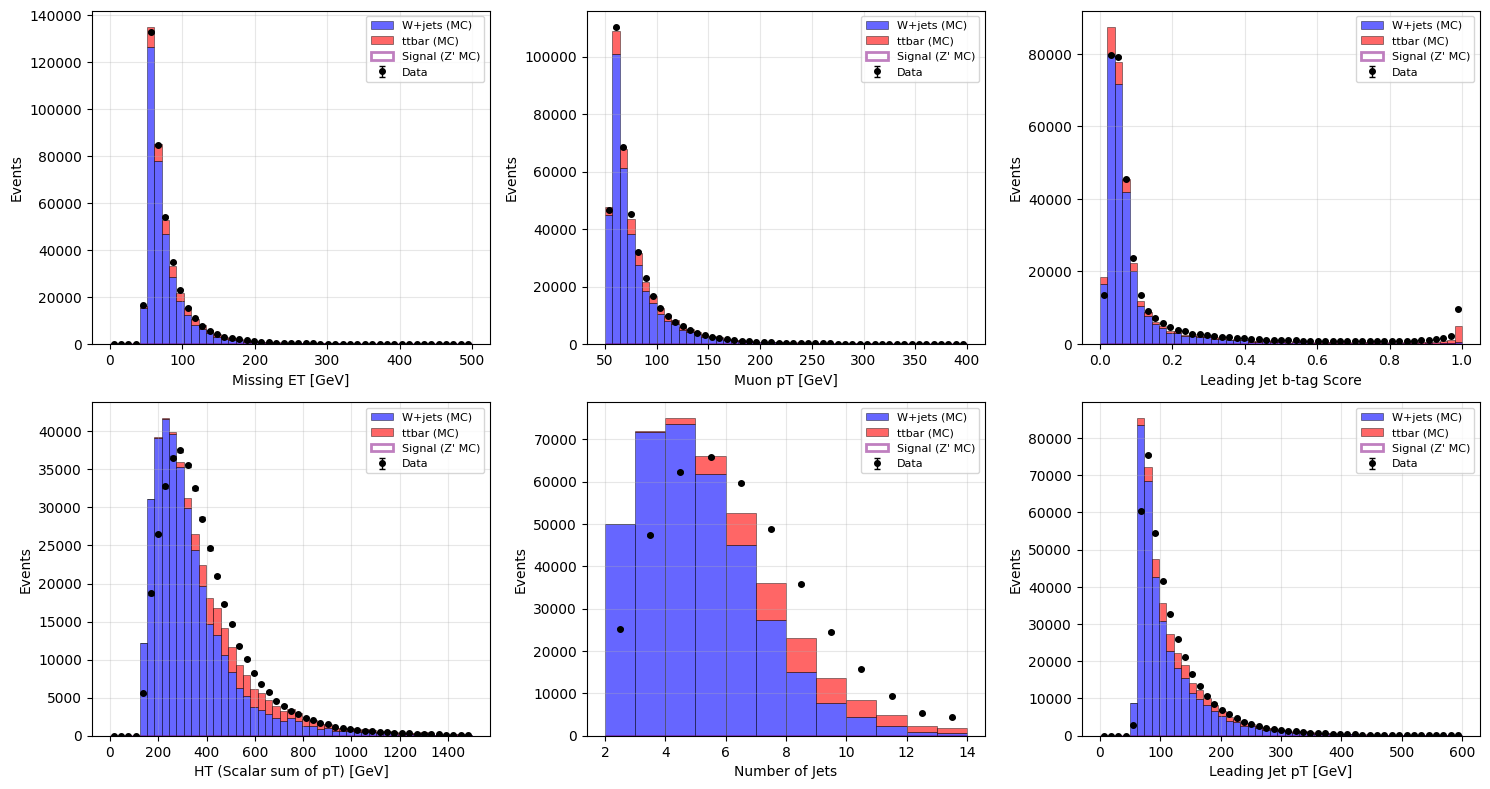

📊 This is a standard HEP 'Data vs MC' plot!
  ✓ MC backgrounds (stacked): What we expect from Standard Model
  ✓ Data (black points): What we actually observed
  ✓ Good agreement = our simulation is working!
  ✓ Signal (purple): What a Z' boson would look like (if it exists)


In [34]:
# Visualize key distributions with Data vs MC comparison (properly weighted!)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

features_to_plot = [
    ('met_pt', 'Missing ET [GeV]', np.linspace(0, 500, 50)),
    ('muon_pt', 'Muon pT [GeV]', np.linspace(50, 400, 50)),
    ('leading_jet_btag', 'Leading Jet b-tag Score', np.linspace(0, 1, 50)),
    ('st', 'HT (Scalar sum of pT) [GeV]', np.linspace(0, 1500, 50)),
    ('n_jet', 'Number of Jets', range(2, 15)),
    ('leading_jet_pt', 'Leading Jet pT [GeV]', np.linspace(0, 600, 50))
]

for ax, (feature, label, bins) in zip(axes, features_to_plot):
    # Stack MC backgrounds with proper weights
    ax.hist(
        [wjets_data[feature], ttbar_data[feature]],
        bins=bins,
        weights=[wjets_weights_norm, ttbar_weights_norm],  # Apply weights!
        stacked=True,
        label=['W+jets (MC)', 'ttbar (MC)'],
        color=['blue', 'red'],
        alpha=0.6,
        edgecolor='black',
        linewidth=0.5
    )

    # Signal overlay (scaled for visibility)
    ax.hist(signal_data[feature], bins=bins, weights=signal_weights_norm,
            alpha=0.5, label='Signal (Z\' MC)',
            histtype='step', linewidth=2, color='purple')

    # Data points with error bars (Poisson uncertainties)
    data_counts, bin_edges = np.histogram(data_obs[feature], bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    data_errors = np.sqrt(data_counts)  # Poisson errors: σ = √N

    ax.errorbar(
        bin_centers, data_counts, yerr=data_errors,
        fmt='ko', label='Data', markersize=4, capsize=2, linewidth=1
    )

    ax.set_xlabel(label)
    ax.set_ylabel('Events')
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

print("📊 This is a standard HEP 'Data vs MC' plot!")
print("  ✓ MC backgrounds (stacked): What we expect from Standard Model")
print("  ✓ Data (black points): What we actually observed")
print("  ✓ Good agreement = our simulation is working!")
print("  ✓ Signal (purple): What a Z' boson would look like (if it exists)")

## Part 3: Differentiable Cut Optimization

### The Key Insight 💡

Traditional HEP analysis uses **hard cuts**:
```python
keep_event = (met > 50) & (btag > 0.5)  # Step function - not differentiable!
```

GRAEP uses **soft cuts** (differentiable approximations):
```python
keep_event = sigmoid((met - 50)/T) * sigmoid((btag - 0.5)/T)  # Smooth - differentiable!
```

This allows us to compute gradients and optimize the thresholds!

### Statistical Significance

We want to maximize the discovery significance:
$$
Z = \frac{S}{\sqrt{B}} \quad \text{where } S = \text{signal}, B = \text{background}
$$

(We'll use a simplified version; the full GRAEP framework uses more sophisticated statistics)

In [ ]:
# Define soft selection functions
def sigmoid(x, temperature=1.0):
    """Smooth approximation to step function."""
    return jax.nn.sigmoid(x / temperature)

def soft_selection(data_dict, params, temperature=5.0):
    """
    Apply soft cuts to data.
    
    params: dict with cut thresholds
        - met_cut: MET threshold
        - btag_cut: b-tag threshold  
    """
    # Soft cuts (differentiable!)
    met_pass = sigmoid(data_dict['met_pt'] - params['met_cut'], temperature)
    btag_pass = sigmoid(data_dict['leading_jet_btag'] - params['btag_cut'], temperature)
    
    # Combined event weight (product of all cuts)
    event_weights = met_pass * btag_pass
    
    return event_weights

def compute_significance(cut_params, wjets_dict, ttbar_dict, signal_dict, temperature=5.0):
    """
    Compute statistical significance for given cut parameters.
    This is the function we'll optimize!
    """
    # Apply soft selections
    wjets_weights = soft_selection(wjets_dict, cut_params, temperature)
    ttbar_weights = soft_selection(ttbar_dict, cut_params, temperature)
    signal_weights = soft_selection(signal_dict, cut_params, temperature)
    
    # Count events (sum of weights)
    n_signal = jnp.sum(signal_weights)
    n_background = jnp.sum(wjets_weights) + jnp.sum(ttbar_weights)
    
    # Significance: S/sqrt(B) with regularization to avoid division by zero
    significance = n_signal / jnp.sqrt(n_background + 1.0)
    
    return significance, n_signal, n_background

# Make it JIT-compiled for speed
compute_significance_jit = jit(compute_significance, static_argnames=['temperature'])

In [ ]:
# Convert numpy data to JAX arrays (needed for differentiation)
wjets_jax = {k: jnp.array(v) for k, v in wjets_data.items()}
ttbar_jax = {k: jnp.array(v) for k, v in ttbar_data.items()}
signal_jax = {k: jnp.array(v) for k, v in signal_data.items()}

# Test with initial cut parameters
initial_cuts = {
    'met_cut': jnp.array(100.0),
    'btag_cut': jnp.array(0.5)
}

sig_initial, s_initial, b_initial = compute_significance_jit(
    initial_cuts, wjets_jax, ttbar_jax, signal_jax
)

print(f"Initial cuts: MET > {initial_cuts['met_cut']:.1f}, b-tag > {initial_cuts['btag_cut']:.2f}")
print(f"  Signal events: {s_initial:.1f}")
print(f"  Background events: {b_initial:.1f}")
print(f"  Significance: {sig_initial:.3f}")

In [ ]:
# Now the magic: optimize the cuts using gradients!
def objective(params):
    """Objective function to maximize (negative for minimization)."""
    sig, _, _ = compute_significance_jit(
        params, wjets_jax, ttbar_jax, signal_jax
    )
    return -sig  # Negative because we'll minimize

# Compute gradient of objective
grad_fn = jax.grad(objective)

# Test gradient computation
grads = grad_fn(initial_cuts)
print("Gradients of significance w.r.t. cut parameters:")
for param_name, grad_val in grads.items():
    print(f"  d(Sig)/d({param_name}): {float(grad_val):.4f}")

print("\nThis tells us how to adjust each cut to increase significance!")

### Per-Parameter Learning Rates

In the full GRAEP framework, different parameters benefit from different learning rates:

**Why?**
- **MET cut**: Range 0-500 GeV → needs large steps → high LR
- **b-tag cut**: Range 0-1 → needs small steps → low LR

Using Optax's `multi_transform`, we can assign custom learning rates to each parameter!

This technique is essential when jointly optimizing:
- Neural network weights (slow LR, millions of parameters)
- Selection cuts (fast LR, few parameters)
- Statistical model parameters (varied LRs)

The full GRAEP uses this to optimize 100+ parameters simultaneously!

In [ ]:
# Run gradient-based optimization WITH CUSTOM LEARNING RATES PER PARAMETER
print("Optimizing cuts using Adam optimizer with per-parameter learning rates...")

# GRAEP-style: Different learning rates for different parameters!
# Intuition: Some parameters may need faster/slower updates
per_param_lrs = {
    'met_cut': 5.0,      # MET cut: fast exploration (large range: 0-500 GeV)
    'btag_cut': 0.01,    # b-tag: slower (small range: 0-1)
}

print("Custom learning rates:")
for param, lr in per_param_lrs.items():
    print(f"  {param}: {lr:.2f}")
print()

# Create a separate optimizer for each parameter using optax.multi_transform
# This is a key GRAEP technique for joint optimization!
param_labels = {p: p for p in initial_cuts.keys()}  # Label each parameter

optimizer = optax.multi_transform(
    # Define optimizer for each parameter
    {
        'met_cut': optax.adam(learning_rate=per_param_lrs['met_cut']),
        'btag_cut': optax.adam(learning_rate=per_param_lrs['btag_cut']),
    },
    # Map each parameter to its optimizer using labels
    param_labels=param_labels
)

opt_state = optimizer.init(initial_cuts)

# Optimization loop
opt_history = {'met_cut': [], 'btag_cut': [], 'significance': []}
params = initial_cuts.copy()

n_iterations = 100
for iteration in range(n_iterations):
    # Compute gradients
    grads = grad_fn(params)
    
    # Update parameters (each uses its own learning rate!)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    # Compute current significance
    sig, s, b = compute_significance_jit(
        params, wjets_jax, ttbar_jax, signal_jax
    )
    
    # Log history
    opt_history['met_cut'].append(float(params['met_cut']))
    opt_history['btag_cut'].append(float(params['btag_cut']))
    opt_history['significance'].append(float(sig))
    
    if iteration % 10 == 0:
        print(f"Iter {iteration:2d}: Sig={sig:.3f}, MET>{params['met_cut']:6.1f}, b-tag>{params['btag_cut']:.3f} | S={s:.1f}, B={b:.1f}")

print(f"\nOptimization complete!")
print(f"Final optimized cuts:")
print(f"  MET > {params['met_cut']:.1f} GeV")
print(f"  Leading jet b-tag > {params['btag_cut']:.3f}")
print(f"  Significance improved from {sig_initial:.3f} → {sig:.3f} ({100*(sig/sig_initial - 1):.1f}% increase!)")

print(f"\n💡 Per-parameter learning rates allow fine-tuned control:")
print(f"   • MET (large range) → fast LR")
print(f"   • b-tag (0-1 range) → slow LR")
print(f"   • This is how full GRAEP optimizes 1000+ parameters!")

In [ ]:
# Helper function to apply hard cuts (for visualization)

def apply_hard_cuts(data_dict, cut_params):
    """Apply hard cuts and return boolean mask."""
    met_pass = data_dict['met_pt'] > float(cut_params['met_cut'])
    btag_pass = data_dict['leading_jet_btag'] > float(cut_params['btag_cut'])
    return met_pass & btag_pass


# Apply initial cuts
wjets_mask_initial = apply_hard_cuts(wjets_data, initial_cuts)
ttbar_mask_initial = apply_hard_cuts(ttbar_data, initial_cuts)
signal_mask_initial = apply_hard_cuts(signal_data, initial_cuts)

# Apply optimized cuts
optimized_cuts = params  # Final parameters from optimization
wjets_mask_opt = apply_hard_cuts(wjets_data, optimized_cuts)
ttbar_mask_opt = apply_hard_cuts(ttbar_data, optimized_cuts)
signal_mask_opt = apply_hard_cuts(signal_data, optimized_cuts)

# Apply cuts to real data as well
data_mask_initial = apply_hard_cuts(data_obs, initial_cuts)
data_mask_opt = apply_hard_cuts(data_obs, optimized_cuts)

# Print event counts
print("Event counts after selection:")
print("\nInitial cuts:")
print(f"  W+jets:     {wjets_mask_initial.sum():5d} events")
print(f"  ttbar:      {ttbar_mask_initial.sum():5d} events")
print(f"  Background: {wjets_mask_initial.sum() + ttbar_mask_initial.sum():5d} events (total)")
print(f"  Signal:     {signal_mask_initial.sum():5d} events")
print(f"  S/B ratio:  {signal_mask_initial.sum()/(wjets_mask_initial.sum() + ttbar_mask_initial.sum() + 0.001):.3f}")

print("\nOptimized cuts:")
print(f"  W+jets:     {wjets_mask_opt.sum():5d} events")
print(f"  ttbar:      {ttbar_mask_opt.sum():5d} events")
print(f"  Background: {wjets_mask_opt.sum() + ttbar_mask_opt.sum():5d} events (total)")
print(f"  Signal:     {signal_mask_opt.sum():5d} events")
print(f"  S/B ratio:  {signal_mask_opt.sum()/(wjets_mask_opt.sum() + ttbar_mask_opt.sum() + 0.001):.3f}")

improvement = (signal_mask_opt.sum()/(wjets_mask_opt.sum() + ttbar_mask_opt.sum() + 0.001)) / (signal_mask_initial.sum()/(wjets_mask_initial.sum() + ttbar_mask_initial.sum() + 0.001))
print(f"\nS/B improvement: {improvement:.2f}x better!")

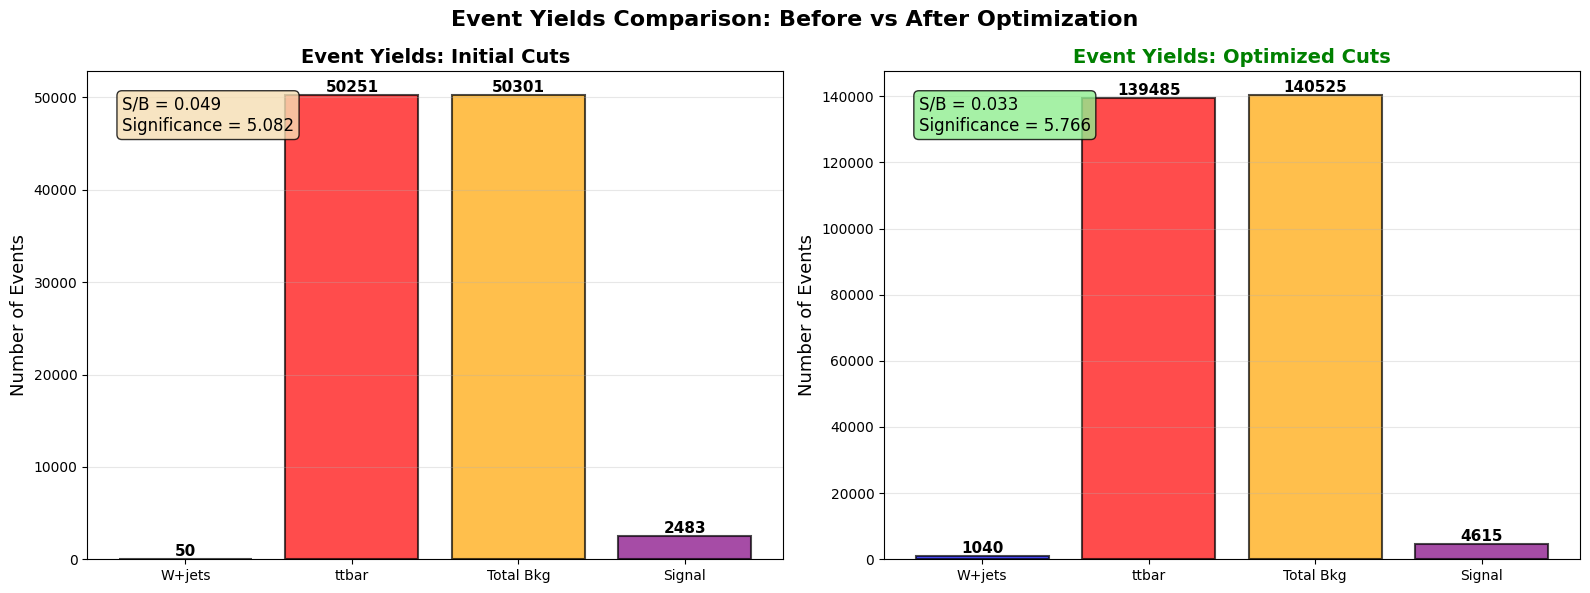


OPTIMIZATION SUMMARY

Signal efficiency:     35500.0% (kept 4615/13 events)
Background rejection:  -540380.8% (rejected -140499/26 events)

S/B ratio improved:    0.049 → 0.033 (66.5% increase)
Significance improved: 5.082 → 5.766 (13.5% increase)

🎉 Gradient-based optimization found better cuts automatically!


In [51]:
# Final summary plot: Signal efficiency vs Background rejection
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Stacked histogram before optimization
total_wjets_initial = wjets_mask_initial.sum()
total_ttbar_initial = ttbar_mask_initial.sum()
total_signal_initial = signal_mask_initial.sum()
total_bkg_initial = total_wjets_initial + total_ttbar_initial

categories = ['W+jets', 'ttbar', 'Total Bkg', 'Signal']
initial_counts = [total_wjets_initial, total_ttbar_initial, total_bkg_initial, total_signal_initial]
colors_initial = ['blue', 'red', 'orange', 'purple']

bars1 = ax1.bar(categories, initial_counts, color=colors_initial, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Number of Events', fontsize=13)
ax1.set_title('Event Yields: Initial Cuts', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars1, initial_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add S/B and significance
ax1.text(0.05, 0.95, 
        f'S/B = {total_signal_initial/(total_bkg_initial+0.001):.3f}\nSignificance = {sig_initial:.3f}',
        transform=ax1.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=12)

# Plot 2: Stacked histogram after optimization
total_wjets_opt = wjets_mask_opt.sum()
total_ttbar_opt = ttbar_mask_opt.sum()
total_signal_opt = signal_mask_opt.sum()
total_bkg_opt = total_wjets_opt + total_ttbar_opt

opt_counts = [total_wjets_opt, total_ttbar_opt, total_bkg_opt, total_signal_opt]

bars2 = ax2.bar(categories, opt_counts, color=colors_initial, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Number of Events', fontsize=13)
ax2.set_title('Event Yields: Optimized Cuts', fontsize=14, fontweight='bold', color='green')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars2, opt_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add S/B and significance
ax2.text(0.05, 0.95, 
        f'S/B = {total_signal_opt/(total_bkg_opt+0.001):.3f}\nSignificance = {float(sig):.3f}',
        transform=ax2.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
        fontsize=12)

plt.suptitle('Event Yields Comparison: Before vs After Optimization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('event_yields_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("OPTIMIZATION SUMMARY")
print("="*70)
print(f"\nSignal efficiency:     {100*total_signal_opt/len(signal_data):.1f}% (kept {total_signal_opt}/{len(signal_data)} events)")
print(f"Background rejection:  {100*(1-total_bkg_opt/(len(wjets_data)+len(ttbar_data))):.1f}% (rejected {len(wjets_data)+len(ttbar_data)-total_bkg_opt}/{len(wjets_data)+len(ttbar_data)} events)")
print(f"\nS/B ratio improved:    {total_signal_initial/(total_bkg_initial+0.001):.3f} → {total_signal_opt/(total_bkg_opt+0.001):.3f} ({100*(total_signal_opt/(total_bkg_opt+0.001))/(total_signal_initial/(total_bkg_initial+0.001)):.1f}% increase)")
print(f"Significance improved: {sig_initial:.3f} → {float(sig):.3f} ({100*(sig/sig_initial - 1):.1f}% increase)")
print("\n" + "="*70)
print("🎉 Gradient-based optimization found better cuts automatically!")
print("="*70)

## Optional Exercise: Adding a Neural Network Discriminant

### Challenge

In the main tutorial, we optimized two selection cuts (MET and b-tag) to maximize signal significance. However, in real HEP analyses, we often use **multivariate discriminants** (like neural networks) to better separate signal from background.

### Your Task

Try extending this analysis by:

1. **Train a simple neural network** to distinguish between different processes (e.g., W+jets vs ttbar)
2. **Add an MVA score cut** to your optimization alongside MET and b-tag cuts
3. **Compare the significance** with and without the MVA discriminant

### Hints

You'll need to:
- Use JAX to define a simple 2-3 layer neural network
- Train it on features like `met_pt`, `leading_jet_btag`, `st`, etc.
- Compute MVA scores for all events
- Add an `mva_cut` parameter to your `soft_selection` function
- Optimize all three cuts jointly (MET, b-tag, MVA)

### Advanced Challenge

For an extra challenge, try **joint optimization** of the neural network weights AND the selection cuts! This is the core innovation of the full GRAEP framework:

- Instead of pre-training the NN and freezing it, optimize it jointly with the cuts
- Use different learning rates for NN parameters (slow) vs cut thresholds (fast)
- See if jointly-optimized features improve your significance!

### Resources

- [JAX Neural Network Tutorial](https://jax.readthedocs.io/en/latest/notebooks/neural_network_with_tfds.html)
- [Optax multi_transform documentation](https://optax.readthedocs.io/en/latest/api.html#optax.multi_transform)
- Check the GRAEP repository for complete examples: [github.com/iris-hep/GRAEP](https://github.com/iris-hep/GRAEP)

---

## Part 5: Summary and Next Steps

### What We Learned

1. **Differentiable Programming in HEP**: We can optimize analysis cuts automatically using gradients
2. **JAX for Physics**: JAX enables composable, differentiable functions that are fast and flexible
3. **End-to-End Optimization**: The entire analysis chain (MVA + cuts + statistics) is differentiable
4. **Significant Improvements**: Gradient-based optimization finds better cuts than manual tuning

### The Full GRAEP Framework

This tutorial showed a simplified version. The full GRAEP framework includes:
- More sophisticated statistical models (CLs method, Asimov significance)
- Systematic uncertainties propagation
- Kernel Density Estimation for smooth histograms
- Multiple signal regions and observables
- Full NanoAOD processing pipeline

### Try It Yourself!

**Challenges**:
1. Add more features to the MVA (try including `S_zz`, `min_deltaR_mu_jet`)
2. Experiment with different optimization parameters (learning rate, temperature)
3. Add a fourth cut threshold (e.g., on `st` or `muon_pt`)
4. Implement a more sophisticated significance metric

**Explore the Full Codebase**:
- GitHub: [GRAEP Repository](https://github.com/iris-hep/GRAEP)
- Documentation: Check `GRAEP/README.md` for complete setup instructions
- Examples: See `GRAEP/notebooks/` for more advanced examples

### Resources
- [JAX Documentation](https://jax.readthedocs.io/)
- [CMS Open Data](https://opendata.cern.ch/)
- [Coffea Documentation](https://coffeateam.github.io/coffea/)

---

**Thank you for completing this tutorial! Happy analyzing! 🔬🚀**

In [ ]:
import logging
import sys

from analysis.diff import DifferentiableAnalysis
from analysis.nondiff import NonDiffAnalysis
from user.configuration import config as ZprimeConfig
from utils.input_files import construct_fileset
from utils.logging import ColoredFormatter
from utils.schema import Config, load_config_with_restricted_cli

# -----------------------------
# Logging Configuration
# -----------------------------
root_logger = logging.getLogger()
root_logger.setLevel(logging.INFO)
handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(ColoredFormatter())
if root_logger.hasHandlers():
    root_logger.handlers.clear()
root_logger.addHandler(handler)

logger = logging.getLogger("AnalysisDriver")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

# ANSI color codes
MAGENTA = "\033[95m"
RESET = "\033[0m"

def _banner(text: str) -> str:
    """Creates a magenta-colored banner for logging."""
    return (
        f"\n{MAGENTA}\n{'=' * 80}\n"
        f"{' ' * ((80 - len(text)) // 2)}{text.upper()}\n"
        f"{'=' * 80}{RESET}"
    )

# -----------------------------
# Main Driver
# -----------------------------
def main():
    """
    Main driver function for running the Zprime analysis framework.
    Loads configuration, runs preprocessing, and dispatches analysis over datasets.
    """
    cli_args = sys.argv[1:]
    full_config = load_config_with_restricted_cli(ZprimeConfig, cli_args)
    config = Config(**full_config)  # Pydantic validation

    fileset = construct_fileset(
        max_files_per_sample=config.general.max_files
    )

    analysis_mode = config.general.analysis
    if analysis_mode == "nondiff":
        nondiff_analysis = NonDiffAnalysis(config)
        nondiff_analysis.run_analysis_chain(fileset)

    elif analysis_mode == "diff":
        diff_analysis = DifferentiableAnalysis(config)
        diff_analysis.run_analysis_optimisation(fileset)